In [1]:
#The goal is predicting Q based on Precipitation
#Type: Supervised/ Regression
#Input: P_yesterday/ P_today/ Q_yesterday
#Output: Q_tomorrow/ Q_today
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("BasinObs_7012.csv")
df.info()
df.Julian.value_counts()
df.describe()
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20819 entries, 0 to 20818
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         20819 non-null  object 
 1   Year         20819 non-null  int64  
 2   Month        20819 non-null  int64  
 3   Day          20819 non-null  int64  
 4   P            20819 non-null  float64
 5   E            20819 non-null  float64
 6   Qcmecs       11165 non-null  float64
 7   Qmm          11165 non-null  float64
 8   Q_Missing    20819 non-null  object 
 9   Julian       20819 non-null  int64  
 10  Season       20819 non-null  object 
 11  Season_Year  20819 non-null  int64  
 12  Water_Year   20819 non-null  int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 2.1+ MB


,Date,Year,Month,Day,P,E,Qcmecs,Qmm,Q_Missing,Julian,Season,Season_Year,Water_Year
0,01/01/1961,1961,1,1,2.56150,0.21809,NaN,NaN,Yes,1,W,1961,1961
1,02/01/1961,1961,1,2,6.16380,0.19237,NaN,NaN,Yes,2,W,1961,1961
2,03/01/1961,1961,1,3,0.27350,0.16380,NaN,NaN,Yes,3,W,1961,1961
3,04/01/1961,1961,1,4,0.86795,0.16710,NaN,NaN,Yes,4,W,1961,1961
4,05/01/1961,1961,1,5,4.53670,0.15706,NaN,NaN,Yes,5,W,1961,1961
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20814,27/12/2017,2017,12,27,0.18105,0.14428,NaN,NaN,Yes,361,W,2018,2018
20815,28/12/2017,2017,12,28,5.93920,0.13475,NaN,NaN,Yes,362,W,2018,2018
20816,29/12/2017,2017,12,29,9.97270,0.17406,NaN,NaN,Yes,363,W,2018,2018
20817,30/12/2017,2017,12,30,3.26880,0.23303,NaN,NaN,Yes,364,W,2018,2018


In [3]:
#Finding the days which have Q
df_with_Q = df[df["Qcmecs"].notna()]
df_with_Q['Year'].min()
df_with_Q['Year'].max()

df_with_Qmm = df[df["Qmm"].notna()]
df_with_Qmm['Year'].min()
df_with_Qmm['Year'].max()
df_with_Qmm

,Date,Year,Month,Day,P,E,Qcmecs,Qmm,Q_Missing,Julian,Season,Season_Year,Water_Year
9496,01/01/1987,1987,1,1,1.62850,0.27063,91.051,3.2669,No,1,W,1987,1987
9497,02/01/1987,1987,1,2,0.11168,0.23667,90.686,3.2538,No,2,W,1987,1987
9498,03/01/1987,1987,1,3,2.75120,0.19110,78.098,2.8022,No,3,W,1987,1987
9499,04/01/1987,1987,1,4,1.83070,0.20857,71.932,2.5809,No,4,W,1987,1987
9500,05/01/1987,1987,1,5,0.74479,0.23850,70.925,2.5448,No,5,W,1987,1987
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20781,24/11/2017,2017,11,24,0.81364,0.17556,117.190,4.2048,No,328,A,2017,2018
20782,25/11/2017,2017,11,25,0.81049,0.19098,90.665,3.2531,No,329,A,2017,2018
20783,26/11/2017,2017,11,26,5.36470,0.27060,72.486,2.6008,No,330,A,2017,2018
20784,27/11/2017,2017,11,27,0.65541,0.26031,67.714,2.4296,No,331,A,2017,2018


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Month'}>,
        <Axes: title={'center': 'Day'}>],
       [<Axes: title={'center': 'P'}>, <Axes: title={'center': 'E'}>,
        <Axes: title={'center': 'Qcmecs'}>],
       [<Axes: title={'center': 'Qmm'}>,
        <Axes: title={'center': 'Julian'}>,
        <Axes: title={'center': 'Season_Year'}>],
       [<Axes: title={'center': 'Water_Year'}>, <Axes: >, <Axes: >]],
      dtype=object)

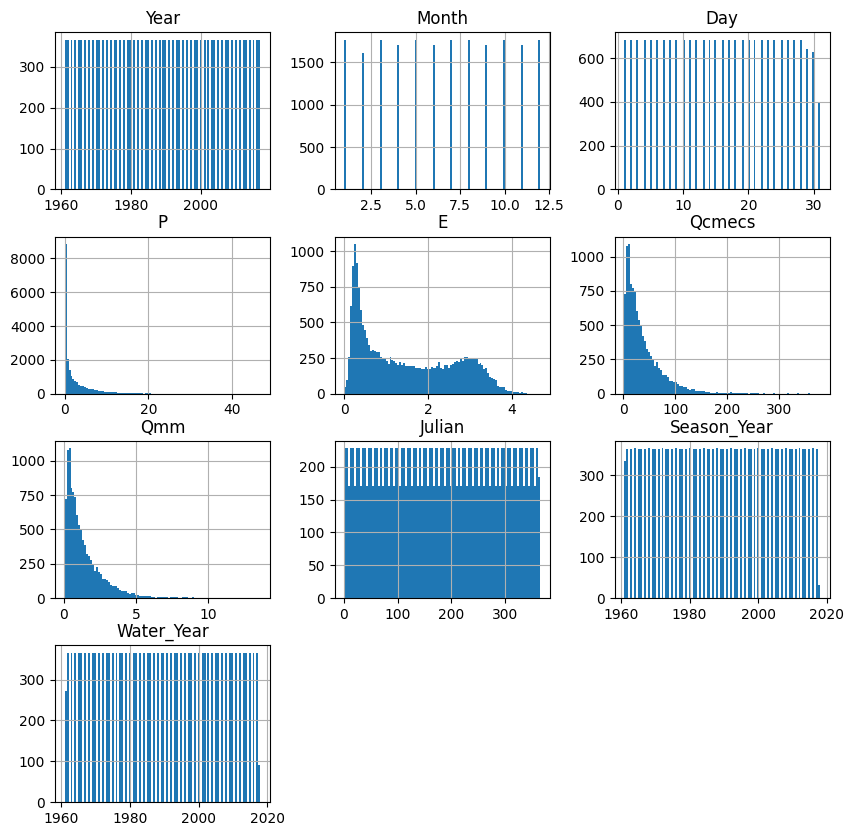

In [4]:
df.hist(bins = 100 , figsize=(10,10))

In [5]:
#Cleaning data- meaning where we have Q (and Q is not NaN)
#1987 onwards
df_hydro = df[df['Year']>= 1987].copy()
print(len(df_hydro))

#see how many NaN you have in df_hydro
print(df_hydro['Qcmecs'].isna().sum())

#now deleting NaN
df_hydro = df_hydro.dropna(subset = ['Qcmecs'])
print(f"Number of days after dropping NaN: {len(df_hydro)} days")

11323
158
Number of days after dropping NaN: 11165 days


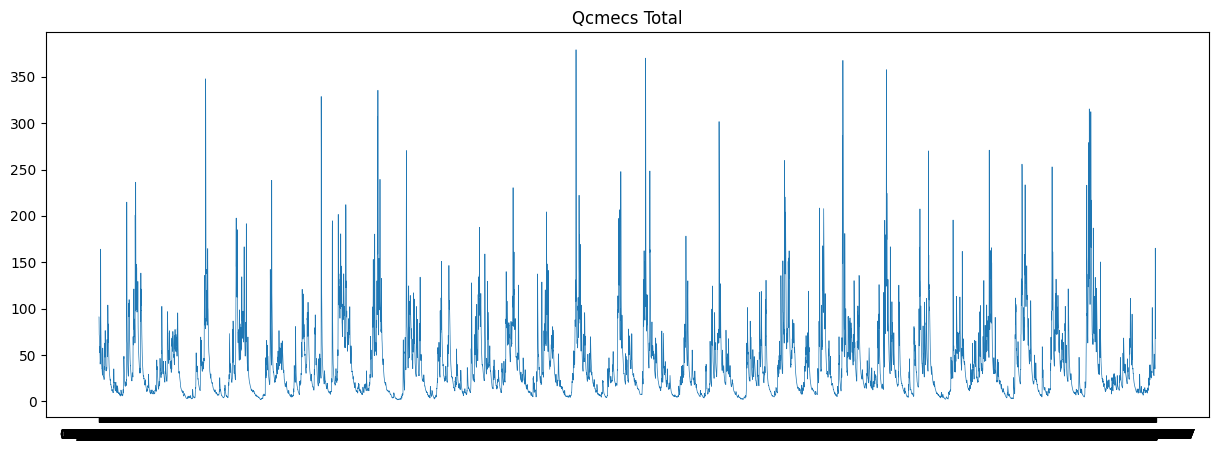

In [6]:
#Checking data via plots

plt.figure(figsize=(15,5))
plt.plot(df_hydro['Date'], df_hydro['Qcmecs'], linewidth=0.5)
plt.title('Qcmecs Total')
plt.show()

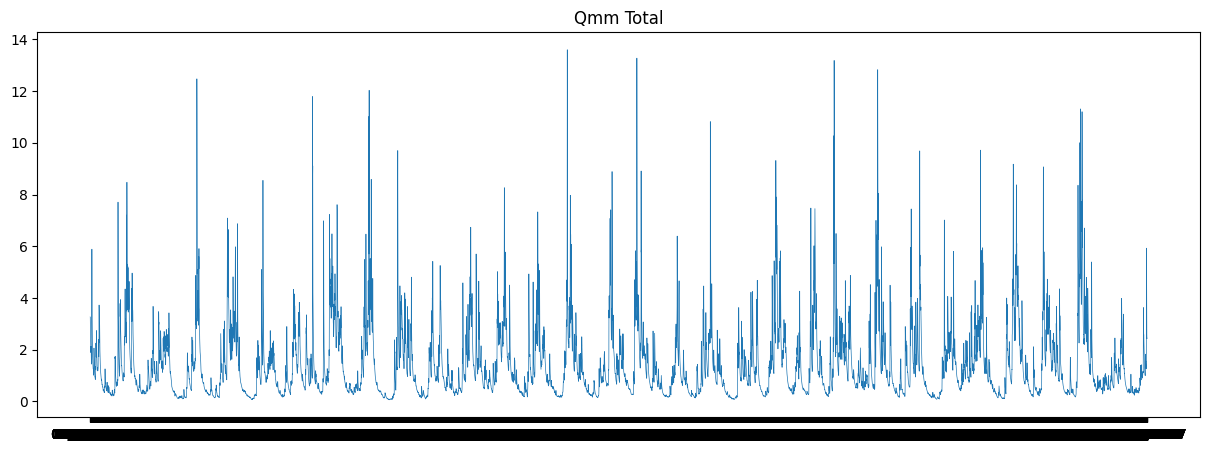

In [7]:
plt.figure(figsize=(15,5))
plt.plot(df_hydro['Date'], df_hydro['Qmm'], linewidth=0.5)
plt.title('Qmm Total')
plt.show()

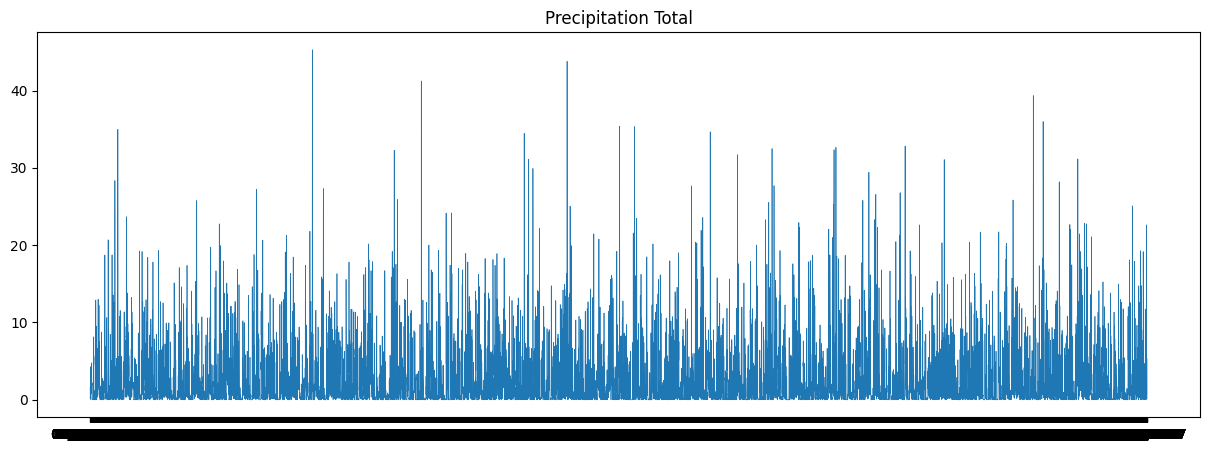

In [8]:
plt.figure(figsize=(15,5))
plt.plot(df_hydro['Date'], df_hydro['P'], linewidth=0.5)
plt.title('Precipitation Total')
plt.show()

   Year    P_mean     Q_mean
0  1987  2.230337  32.922666
1  1988  2.559781  40.687631
2  1989  2.140718  27.166872
3  1990  2.627052  36.418326
4  1991  2.344813  37.798507
Yearly data:
   Year    P_mean
0  1987  2.230337
1  1988  2.559781
2  1989  2.140718
3  1990  2.627052
4  1991  2.344813

 Annual Q:
   Year     Q_mean
0  1987  32.922666
1  1988  40.687631
2  1989  27.166872
3  1990  36.418326
4  1991  37.798507


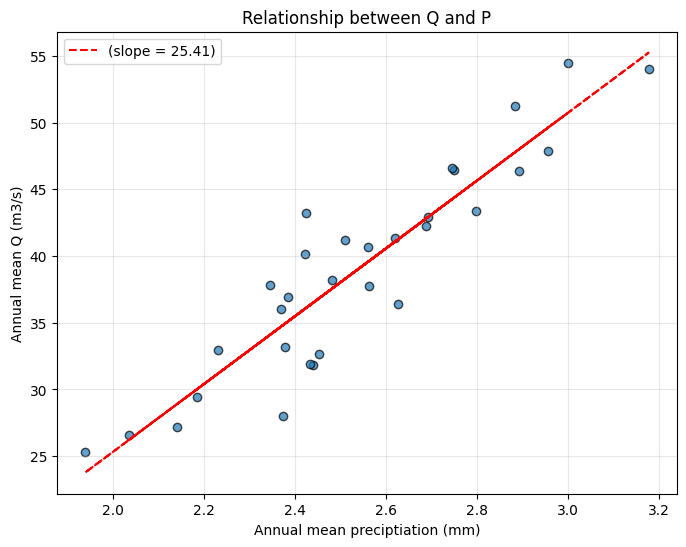

NameError: name 'correlation' is not defined

In [9]:
#Cuz the data is not normally distributed, we will use non-parametric tests such as Mann-Kendall test to see the trends (if there is based on p-value)
import pymannkendall as mk
#mean annual precipitation
yearly_P = df_hydro.groupby('Year')['P'].mean().reset_index()
yearly_P.columns =['Year','P_mean']

yearly_Q = df_hydro.groupby('Year')['Qcmecs'].mean().reset_index()
yearly_Q.columns =['Year','Q_mean']

yearly_data = yearly_P.merge(yearly_Q, on='Year')
print(yearly_data.head())

print('Yearly data:')
print(yearly_P.head())
print('\n Annual Q:')
print(yearly_Q.head())

#Before trend analysis, we simply plot Annual Q vs P (to see the  + and - relationship between two varaibles- scatter plot)
plt.figure(figsize=(8,6))
plt.scatter(yearly_data['P_mean'], yearly_data['Q_mean'], alpha= 0.7,edgecolors='black')
plt.xlabel('Annual mean preciptiation (mm)')
plt.ylabel('Annual mean Q (m3/s)')
plt.title('Relationship between Q and P')
plt.grid(True, alpha = 0.3)

#adding simple linear regression
z = np.polyfit(yearly_data['P_mean'], yearly_data['Q_mean'],1)
p = np.poly1d(z)
plt.plot(yearly_data['P_mean'], p(yearly_data['P_mean']), 'r--', label = f'(slope = {z[0]:.2f})')
plt.legend()
plt.show()

#Calculating correlation ratiocorrelation = yearly_data['P_mean'].corr(yearly_data['Q_mean'])
print(f'correlation:{correlation}')

In [10]:
#Mann-Kendall Test for analysimg trends
import pymannkendall as mk
#using 1987 onwards data df_hydro
result_P = mk.original_test(yearly_P['P_mean'])

print("="*50)
print("Mann-Kendall Test for Annual precipitation (P)")
print("="*50)
print(f'Trend: {result_P.trend}')
print(f'P-value:{result_P.p:.6f}')
print(f'Z-Score:{result_P.z:.4f}')
print(f"Sen's slope:{result_P.slope:.4f}")

if result_P.p < 0.05:
    print("Meaningful trend")
else:
    print("No meaningful trend")


Mann-Kendall Test for Annual precipitation (P)
Trend: no trend
P-value:0.261963
Z-Score:1.1218
Sen's slope:0.0077
No meaningful trend


In [11]:
result_Q = mk.original_test(yearly_Q['Q_mean'])

print("="*50)
print("Mann-Kendall Test for Annual Runoff (Q)")
print("="*50)
print(f'Trend: {result_Q.trend}')
print(f'P-value:{result_Q.p:.6f}')
print(f'Z-Score:{result_Q.z:.4f}')
print(f"Sen's slope:{result_Q.slope:.4f}")

if result_Q.p < 0.05:
    print("Meaningful trend")
else:
    print("No meaningful trend")

Mann-Kendall Test for Annual Runoff (Q)
Trend: no trend
P-value:0.276696
Z-Score:1.0878
Sen's slope:0.1574
No meaningful trend


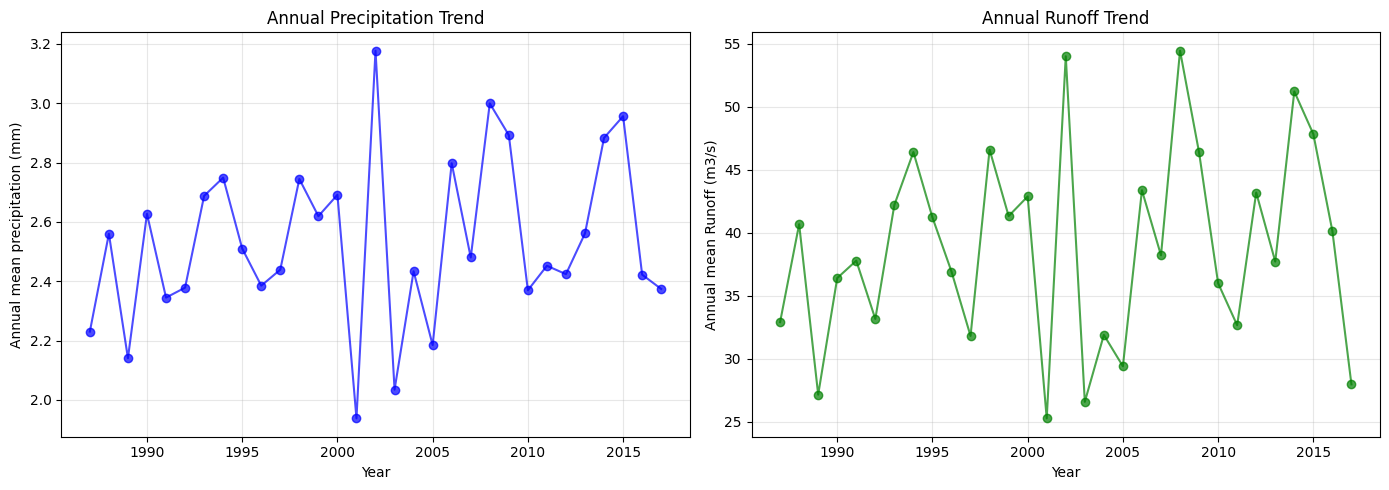

In [12]:
#Visulaizing Trends based on Mann Kendall 
fig, axes = plt.subplots (1,2, figsize= (14,5))

#Precipitation (P)
axes[0].plot(yearly_P['Year'], yearly_P['P_mean'], 'o-'  ,color= 'blue', alpha = 0.7)
axes[0].set_title('Annual Precipitation Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Annual mean precipitation (mm)')
axes[0].grid(True, alpha=0.3)


#Runoff (Q)
axes[1].plot(yearly_Q['Year'], yearly_Q['Q_mean'], 'o-'  ,color= 'green', alpha = 0.7)
axes[1].set_title('Annual Runoff Trend')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Annual mean Runoff (m3/s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Now we want to split data for train and test we usually get 80% for train and remaining 20% for test. 
#so in hydrology we can't do what we have done in housing prices as the time series is important in hydrological series
#Therefore we can't use the test_train_split function for it. instead we will use 2 other approaches 1- manually 2-scikit TimeSeriesSplit

#Approach 1: MANUALLY
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

#making Q yesterday, P yesterday (lag 1) from df_hydro
df_hydro['Q_lag1'] = df_hydro['Qcmecs'].shift(1)
df_hydro['P_lag1'] = df_hydro ['P']. shift(1)
df_model = df_hydro.dropna().copy()

print(f'Number of final rows for model: {len(df_model)}')
print (df_model[['P', 'P_lag1', 'Qcmecs', 'Q_lag1']].head())


Number of final rows for model: 11164
            P   P_lag1  Qcmecs  Q_lag1
9497  0.11168  1.62850  90.686  91.051
9498  2.75120  0.11168  78.098  90.686
9499  1.83070  2.75120  71.932  78.098
9500  0.74479  1.83070  70.925  71.932
9501  0.10747  0.74479  64.672  70.925


In [14]:
#selecting features (X)
X = df_model [['P' , 'P_lag1' , 'Q_lag1' ]] #Today P, yesterday P and Q
y = df_model ['Qcmecs'] #Today Q
#for anticipating Q tomorrow 
# y = df_model['Qcmecs'].shift(-1).dropna()
#and then aligning X
print (f'Shape X: {X.shape}')
print (f'Shape y: {y.shape}')

Shape X: (11164, 3)
Shape y: (11164,)


In [15]:
#Splitting manually
train_size = int(0.8 * len(df_model))

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

#see the test and train period
print(f'Train period: {df_model['Date'].iloc[0]} to {df_model['Date'].iloc[train_size-1]}')
print(f'Test period: {df_model['Date'].iloc[train_size]} to {df_model['Date'].iloc[-1]}')
print(f'Number of trains: {len(X_train)} | Number of tests: {len(X_test)}')

Train period: 02/01/1987 to 25/07/2011
Test period: 26/07/2011 to 28/11/2017
Number of trains: 8931 | Number of tests: 2233


In [16]:
#Saving splitted data for further use
X_train.to_csv('X_train.csv', index = False)
X_test.to_csv('X_test.csv', index = False)
y_train.to_csv('y_train.csv', index = False)
y_test.to_csv('y_test.csv', index = False)
print("The splitted data has been saved")


The splitted data has been saved


In [17]:
#Now usinf Scikit learn for splitting data "TimeSeriesSplit"
#split1 day[0] for training[1]| day [0,1] for training [2]| Day [0,1,2] for training [3]
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits = 5, test_size = None)
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    print (f'Fold {fold+1}: Train={len(train_index)} days, Test= {len(test_index)} days')

TimeSeriesSplit

Fold 1: Train=1864 days, Test= 1860 days
Fold 2: Train=3724 days, Test= 1860 days
Fold 3: Train=5584 days, Test= 1860 days
Fold 4: Train=7444 days, Test= 1860 days
Fold 5: Train=9304 days, Test= 1860 days


sklearn.model_selection._split.TimeSeriesSplit

=== Assessing the linear regression model===
R2 on Training Data : 0.9144
R2 on Test Data : 0.9350
RMSE on Test Data: 10.84


C:\Users\yoshi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


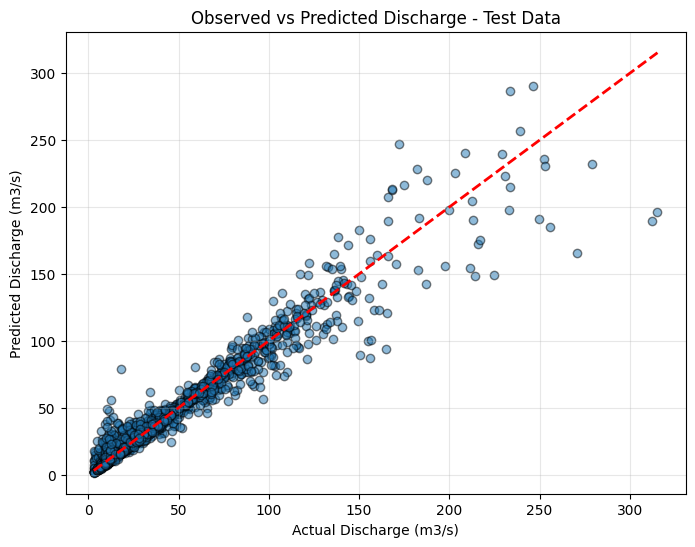

In [27]:
#now since the data is پیوسته we use regression 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

#creat and train the model
model = LinearRegression()
model.fit(X_train, y_train)

#پیش بینی
y_train_pred = model.predict(X_train) #prediction on training data
y_test_pred = model.predict(X_test) #prediction on test data

#ارزیابی مدل
print ('=== Assessing the linear regression model===')
print(f'R2 on Training Data : {r2_score(y_train, y_train_pred):.4f}')
print(f'R2 on Test Data : {r2_score(y_test, y_test_pred):.4f}')
print (f'RMSE on Test Data: {mean_squared_error(y_test, y_test_pred, squared=False):.2f}')

#plot the predicted vs actual values (only for test data)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Discharge (m3/s)')
plt.ylabel('Predicted Discharge (m3/s)')
plt.title('Observed vs Predicted Discharge - Test Data')
plt.grid(True, alpha=0.3)
plt.show()

===Random Forest===
R2: 0.9595
RMSE: 8.56


C:\Users\yoshi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


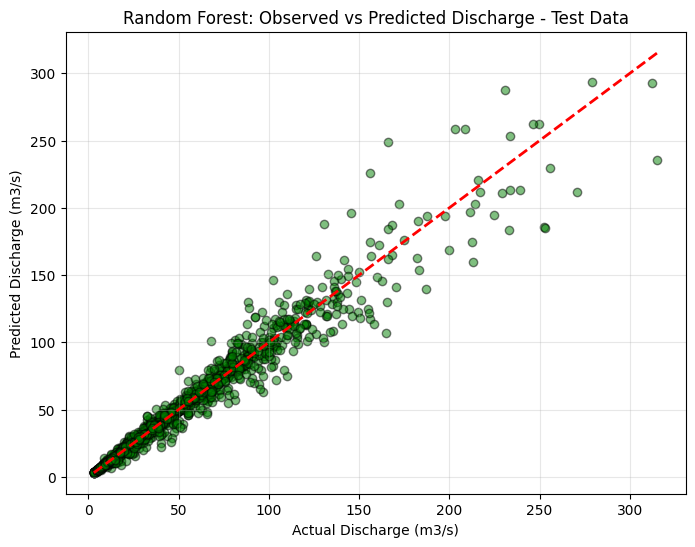

In [32]:
#As we can see in the plot the linear model cannot predict well in high discharges
#Let's try Random Forest
#چرا رندوم فورست رو امتحان کردیم؟ چون مدل رگرسیون برای داده های خطی مناسب است اما داریم میبینیم که رابطه بین دبی و سبل الزاما حطی نیست ممکنه
#در دبی های بالاتر این رابطه دیگه خطی نیست چون ممکنه به ازای فلان قدر بارش فلان قدر به سیل افزوده نشه که به شرایط حوزه و خاک و مواردی بستگی داره
# به همین دلیل رندوم فورست که یک روش درخت تصمیم هست پیشنهاد میشه که در واقع میاد و از پریش های بله و خیر استفاده میکنه تا بتونه درخت های متعدد و تصادفی بسازه و 
# در نهایت از اون ها میانگین بگیره
#وقتی مدل رو ران بگیری متوجه میشی که مقادیر ارزیابی مدل چقدر بهتر شدن
from sklearn.ensemble import RandomForestRegressor

#Making new model this time woth Random Forest
rf_model = RandomForestRegressor(n_estimators = 100, random_state= 42)
rf_model.fit (X_train, y_train)

#Prediction
y_test_pred_rf = rf_model.predict (X_test) #میگه بر اساس این داده هایی که قبلا ندیدی دبی اون ها یعنی y_test_pred_rf رو حدس بزن 

#Evaluation
print('===Random Forest===')
print(f'R2:{r2_score(y_test, y_test_pred_rf): .4f}')
print (f'RMSE: {mean_squared_error(y_test, y_test_pred_rf, squared=False):.2f}')

#plotting RF
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, edgecolor='black', color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Discharge (m3/s)')
plt.ylabel('Predicted Discharge (m3/s)')
plt.title('Random Forest: Observed vs Predicted Discharge - Test Data')
plt.grid(True, alpha=0.3)
plt.show()

===XGBoosT===
R2: 0.9447
RMSE: 10.00


C:\Users\yoshi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


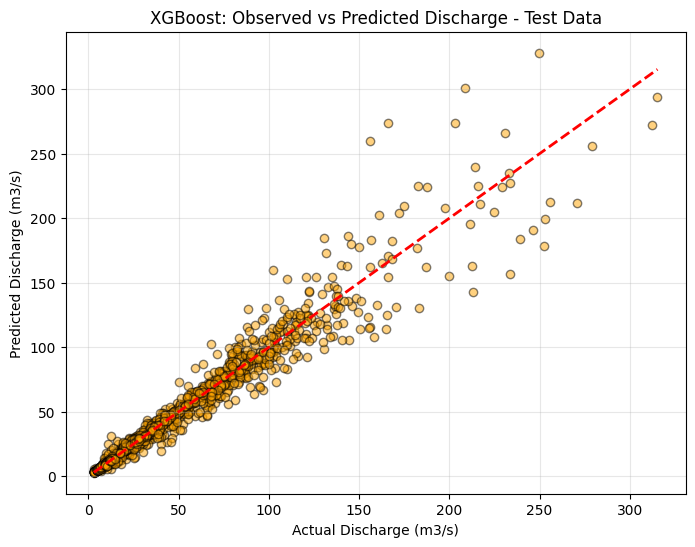

In [49]:
#حالا یکی از ابزار های مهم دیگه مدل 
#XGBOOST
#هست. مشابه رندوم فورست اما درخت ها رو یکی پس از دیگری میسازه و هر درخت سعی میکنه اشتباهات درخت های قبلی رو اصلاح کنه، معمولا از رندوم فورست هم بهتر عمل میکنه
#!pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Making model
xgb_model = XGBRegressor(n_estimators = 100, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

#predict
y_test_pred_xgb = xgb_model.predict(X_test)

#Evaluation
print('===XGBoosT===')
print(f'R2:{r2_score(y_test, y_test_pred_xgb): .4f}')
print (f'RMSE: {mean_squared_error(y_test, y_test_pred_xgb, squared=False):.2f}')

#plotting RF
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred_xgb, alpha=0.5, edgecolor='black', color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Discharge (m3/s)')
plt.ylabel('Predicted Discharge (m3/s)')
plt.title('XGBoost: Observed vs Predicted Discharge - Test Data')
plt.grid(True, alpha=0.3)
plt.show()


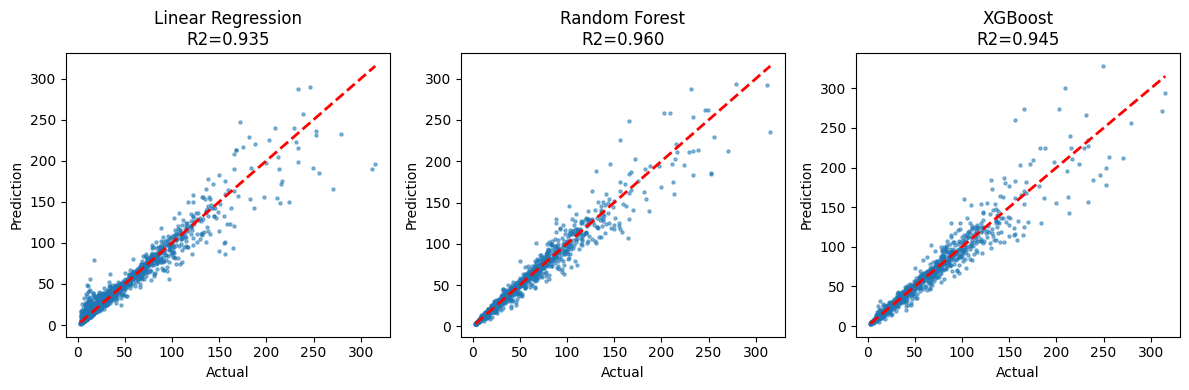

<BarContainer object of 3 artists>

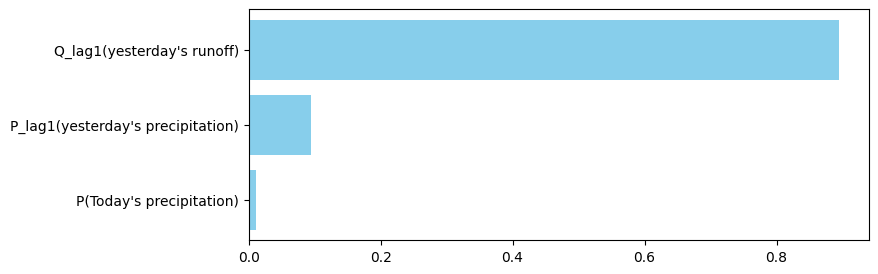

In [54]:

#Now comparing models
import matplotlib.pyplot as plt
models = {
    'Linear Regression': y_test_pred,
    'Random Forest':y_test_pred_rf,
    'XGBoost': y_test_pred_xgb
}

plt.figure(figsize=(12,4))
for i, (name, pred) in enumerate (models.items()):
    plt.subplot(1,3,i+1)
    plt.scatter(y_test, pred, alpha=0.5, s=5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
    plt.title(f'{name}\nR2={r2_score(y_test, pred):.3f}')
    plt.xlabel('Actual')
    plt.ylabel('Prediction')
plt.tight_layout()
plt.show()

#To see which input (P, P_Lag, Q_lag) had the most impact on prediction
importances = rf_model.feature_importances_
feature_names = ["P(Today's precipitation)","P_lag1(yesterday's precipitation)", "Q_lag1(yesterday's runoff)"]

plt.figure(figsize=(8,3))
plt.barh(feature_names,importances,color='skyblue')

#نتیجه میگیریم که در این حوضه، وضعیت دبی دیروز خیلی مهم تر از بارش امروز است. یعنی اگر امروز بدانیم دبی دیروز چقدر بوده، میتونامی دبی امروز را با دقت بالایی پیش بینی کنیم
#حتی بدون دانشتن بارش همان روز

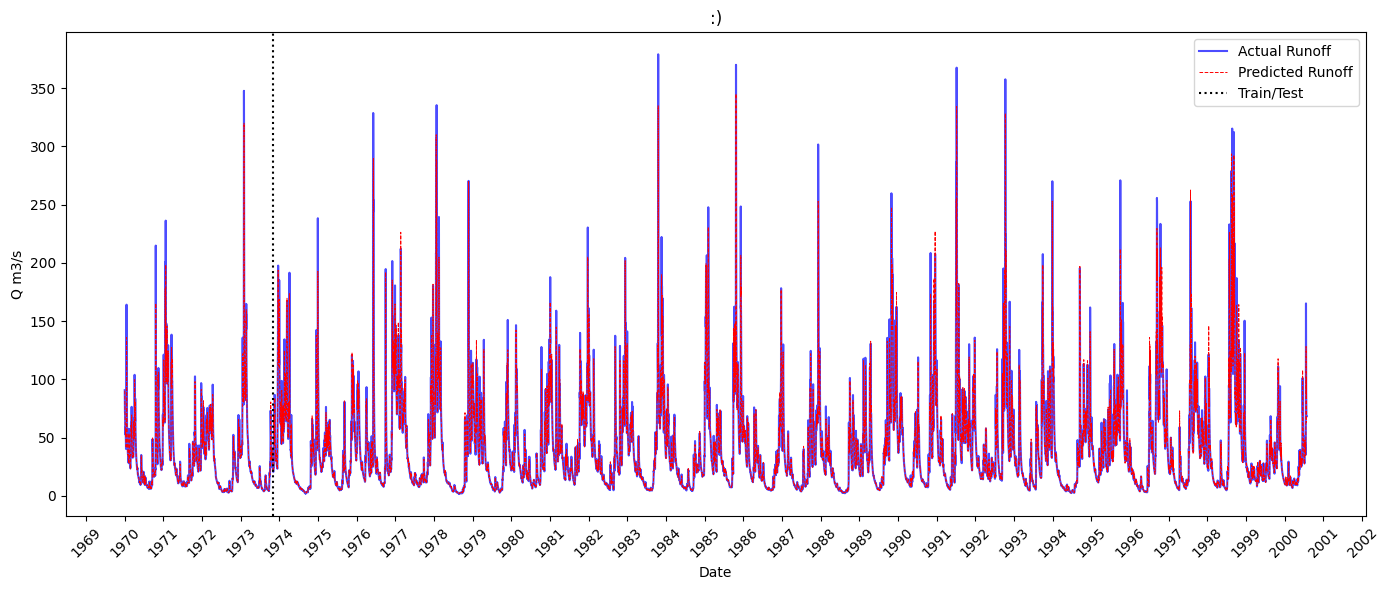

In [84]:
#نمودار سری زمانی کامل: یعنی .تقعیت در مقابل پیش بینی
import matplotlib.pyplot as plt
import pandas as pd
df_plot = df_model.copy()
y_all_pred_rf = rf_model.predict(X)
plt.figure(figsize=(14,6))
plt.plot(df_plot['Date'], y, label='Actual Runoff' , color='blue', linewidth=1.5, alpha=0.7)
df_plot['Q_pred_RF'] = y_all_pred_rf
plt.plot(df_plot['Date'], df_plot['Q_pred_RF'], label= 'Predicted Runoff', color='red', linestyle='--',linewidth=.7, alpha=1 )

plt.axvline(x=1400, color='black', linestyle=':', linewidth= 1.5, label ='Train/Test')
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
plt.title(':)')
plt.xlabel('Date')
plt.ylabel('Q m3/s')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#تاریخ ها رو باید اصلاح بزنی یکم تاریخ ها مشکل دارد